First few basic classes will be introduced

In [1]:
# Python standard libraries
import uuid     # Generally used for generating ids
import random   
import math     

In [2]:
class Position2D():
    '''Class used to keep track of 2D positions in cartesian coordinates'''
    def __init__(self, x: float, y: float):
        self.x = x      # X coordinate of the position
        self.y = y      # Y coordinate of the position

    def __add__(self, other: 'Position2D') -> 'Position2D':
        '''Add two Position2D objects'''
        if not isinstance(other, Position2D):
            raise ValueError("Can only add Position2D to Position2D")
        return Position2D(self.x + other.x, self.y + other.y)
    
    def __sub__(self, other: 'Position2D') -> 'Position2D':
        '''Subtract two Position2D objects'''
        if not isinstance(other, Position2D):
            raise ValueError("Can only subtract Position2D from Position2D")
        return Position2D(self.x - other.x, self.y - other.y)
    
    def scale(self, scalar: float) -> None:
        '''Scale the Position2D by a scalar'''
        self.x = self.x * scalar
        self.y = self.y * scalar
    
    def randomNormalized(self) -> 'Position2D':
        '''Generate a random normalized Position2D'''
        angle = random.uniform(0, 2 * math.pi)
        return Position2D(math.cos(angle), math.sin(angle))

def distance_to(A: Position2D, B: Position2D) -> float:
    '''Calculate the Euclidean distance to another Position2D'''
    return ((A.x - B.x) ** 2 + (A.y - B.y) ** 2) ** 0.5

In [3]:
from abc import ABC, abstractmethod
from asyncio import Task
from enum import Enum, auto

class Agent(ABC):
    '''Abstract base class for agents in a 2D environment'''
    def __init__(self, position: Position2D, task_radius: int, com_radius: int, velocity: int):
        # User parameters
        self._id = uuid.uuid4()                 # Unique identifier for the agent
        self.position = position                # Current position of the agent
        self.com_radius = com_radius            # Communication radius of the agent
        self.task_radius = task_radius          # Task radius of the agent
        self.velocity = velocity                # Velocity of the agent

        # Inner parameters
        self._state = AgentState.MOVING     # Needed for inner state machine
        self._sensorTask = 0.0              # A readout of task signal
        self._sensorCom = None              # A readout of communication signal

    @abstractmethod
    def move(self):
        '''Move the agent to a new position'''
        pass
    
    @abstractmethod
    def writeTaskSensor(self, value: float, task) -> None:
        '''Function to pass information from the environment'''
        pass

    @abstractmethod
    def writeComSensor(self, agent: 'Agent', distance: float) -> None:
        '''Function to pass information from other agents in the environment'''
        pass

    @abstractmethod
    def decide(self) -> None:
        '''Should be called in every iteration -- bascially an implementation of agent behaviour'''
        pass
    
    @abstractmethod
    def taskComplete(self) -> None:
        '''Function to notify the agent that a task has been completed'''
        pass

class AgentState(Enum):
    '''Enumeration for agent states'''
    MOVING = auto()       # Agent is moving
    CALL_OUT = auto()     # Agent detected a task and should inform other agents
    WAITING = auto()      # Agent is waiting for a task to be completed
    RESPONDING = auto()   # Agent received a call-out and tries to find the calling agent

In [4]:
class Task():
    '''Class to represent a task in the environment'''
    def __init__(self, position: Position2D, capacity: int):
        self._id = uuid.uuid4()      # Unique identifier for the task
        self.position = position    # Position of the task in the environment
        self.agents = dict()        # Dict of agents currently in the task_radius = [agent._id] = agent_obj
        self.completed = False      # Boolean indicating if the task has been completed
        self.capacity = capacity    # Amount of agents needed to complete the task

    def add_agent(self, agent: Agent) -> None:
        '''Update the task status based on the number of agents in its radius'''
        self.agents[agent._id] = agent
        if len(self.agents) >= self.capacity:
            self.completed = True

    def remove_agent(self, agent: Agent) -> None:
        '''Remove an agent from the task's agent list'''
        self.agents.pop(agent._id, None)


    def respawn(self, position: Position2D) -> None:
        '''Respawn the task at a new position'''
        self._id = uuid.uuid4()      # Regenerate UUID
        self.position = position
        self.agents = dict()
        self.completed = False

In [5]:
import random


class Environment():
    '''Class for managing agent environment'''
    def __init__(self, size: tuple[int, int], task_count: int, task_capacity: int, task_radius: int, agent_radius: int, agent_count: int, agent_class):
        
        # Environment parameters
        # =============================================================================================
        self.width = size[0]                        # Width of the rectangular 2D environment
        self.height = size[1]                       # Height of the rectangular 2D environment
        self._keepHistory = False                   # Whether to keep history of the environment state

        # Task parameters
        # =============================================================================================
        self.task_count = task_count                # Number of tasks in the environment
        self.task_capacity = task_capacity          # Amount of agents needed in task_radius to complete a task
        self.task_radius = task_radius              # Radius of each task's area of effect
        
        # Agent parameters
        # =============================================================================================
        self.agent_radius = agent_radius            # Radius of the agent communication area
        self.agent_count = agent_count              # Number of agents in the environment
        self.agent = agent_class                    # Class of agents in the environment - must be a subclass of Agent

        # Environment state
        # =============================================================================================
        self.tasks = dict()                                         # Dict of tasks in the environment [task._id] = task_obj
        self.agents = dict()                                        # Dict of agents in the environment [agent._id] = agent_obj
        self.tasks_done = dict()                                    # Keeps track of UUIDs of done tasks and agents UUIDs that completed them
        self.iteration = 0                                          # Current iteration of the environment
        self.history = {"agents": dict(), "tasks": dict()}          # History of the environment state (if needed)

    def initialize(self) -> None:
        '''Initialize the environment with tasks and agents'''

        # Reset agent and task dicts
        self.tasks = dict()
        self.agents = dict()

        # Create tasks
        for _ in range(self.task_count):
            x = random.uniform(0, self.width)
            y = random.uniform(0, self.height)
            task: Task = Task(Position2D(x, y), self.task_capacity)
            self.tasks[task._id] = task
        
        # Create agents
        for _ in range(self.agent_count):
            x = random.uniform(0, self.width)
            y = random.uniform(0, self.height)
            agent: Agent = self.agent(Position2D(x, y))
            self.agents[agent._id] = agent

        # Zero the counters        
        self.tasks_done = dict()
        self.history = {"agents": dict(), "tasks": dict()} 
        self._keepHistory = False
        self.iteration = 0

    def update_taskSensors(self) -> list:
        '''Updates readings of the task signals in agent sensors, returns a list of agents that are in the task radii and can communicate'''
        agentsList = dict()     # This will be used to narrow down the communication search later on

        for agentKey in self.agents:
            for taskKey in self.tasks:
                agent = self.agents[agentKey]
                task = self.tasks[taskKey]

                # Calculate distance
                dist = distance_to(agent.position, task.position)
                if dist <= self.task_radius:
                    task.add_agent(agent)
                    if task._id not in agentsList:
                        agentsList[task._id] = list()
                    agentsList[task._id].append(agent._id)

                # Before updating the sensor, we check if the task is already completed
                if task.completed == False:
                    agent.writeTaskSensor(dist, task)
                    continue

                # If the task is completed, we skip updating the sensor -- otherwise the agent might think it can still contribute
                self.tasks_done[task._id] = {"agents": list(task.agents.keys()), "iteration": self.iteration, "position": task.position}

                # Additionally we pop the agents from the contribution list
                agentsList.pop(task._id, None)
                task.respawn(Position2D(random.uniform(0, self.width), random.uniform(0, self.height)))    # Now new task needs to be spawned
                
                if self._keepHistory == True:
                    if task._id not in self.history["tasks"]:
                        self.history["tasks"][task._id] = dict()
                    self.history["tasks"][task._id]["position"] = task.position

                for a_id in task.agents:
                    a = task.agents[a_id]
                    a.taskComplete()   # Notify agents that the task is complete

        # Finally construct a list of agents
        agents = list()
        for taskKey in agentsList:
            for agent_id in agentsList[taskKey]:
                if agent_id not in agents:
                    agents.append(agent_id)

        return agents

    def update_communicationSensors(self, agentsList: list[Agent]) -> None:
        '''Updates readings of the communication signals in agent sensors'''
        for agent in agentsList:
            for otherKey in self.agents:
                otherAgent = self.agents[otherKey]
                if agent._id == otherAgent._id:
                    # Skip self
                    continue
                
                # Communication only happens between agents that are in the com radius
                dist = distance_to(agent.position, otherAgent.position)
                if dist <= agent.com_radius:
                    agent.writeComSensor(otherAgent, dist)

    def run(self, iterations: int, keep_history: bool = False) -> None:
        '''Run the environment for a specified number of iterations'''
        self.initialize()

        # Prepare history
        self._keepHistory = keep_history
        if self._keepHistory == True:
            # Add tasks to history
            for taskKey in self.tasks:
                task = self.tasks[taskKey]
                self.history["tasks"][task._id] = dict()
                self.history["tasks"]["capacity"] = self.task_capacity
                self.history["tasks"]["radius"] = self.task_radius
                self.history["tasks"][task._id]['position'] = task.position

        for _ in range(iterations):
            # First we update sensors and tasks
            agentList = self.update_taskSensors()
            self.update_communicationSensors(agentList)

            # Then we let agents decide
            for agentKey in self.agents:
                agent = self.agents[agentKey]
                agent.decide()

                # Archive
                if self._keepHistory == True:
                    if agent._id not in self.history["agents"]:
                        self.history["agents"][agent._id] = dict()

                    if 'position' not in self.history["agents"][agent._id]:
                        self.history["agents"][agent._id]['position'] = list()
                    self.history["agents"][agent._id]['position'].append(agent.position)
                    self.history["agents"][agent._id]['state'] = agent._state.name

            self.iteration += 1
            

    def test_run(self):
        '''Run a simple test of the environment'''
        self.initialize()
        position =  [list(), list()]
        for _ in range(1000):
            self.iteration += 1
            #print(f"Iteration: {self.iteration}")
            for agent in self.agents:
                agent.move()
                position[0].append(agent.position.x)
                position[1].append(agent.position.y)
                #print(f"Agent {agent._id} moved to position ({agent.position.x}, {agent.position.y})")

        return position[0], position[1]

    def __repr__(self) -> str:
        return f"Environment(width={self.width}, height={self.height}, task_count={self.task_count}, task_capacity={self.task_capacity}, task_radius={self.task_radius}, agent_radius={self.agent_radius})"



### Implementation of simple agent

In [6]:
class SimpleAgent(Agent):
    '''A simple agent that moves randomly within the environment'''
    def __init__(self, position: Position2D, env_size: tuple[int, int], task_radius:int, com_radius: int, velocity: int):
        super().__init__(position, task_radius, com_radius, velocity)
        self._boundary = env_size

    def move(self):
        '''Move the agent to a new position -- perform random walk'''
        velocity_vector = Position2D(0, 0).randomNormalized()   
        velocity_vector.scale(self.velocity)
        new_position = self.position + velocity_vector 

        # Check for boundary collisions
        if 0 <= new_position.x <= self._boundary[0] and 0 <= new_position.y <= self._boundary[1]:
            self.position = new_position
        else:
            # If out of bounds then agent should:
            # 1. Move to the boundary
            # 2. "Reroll" movement 
            # 3. Go rest of the distance within bounds
            first_scale = 1.0
            dist_x, dist_y = 0, 0

            # The movement after the boundary hit
            second_movement = Position2D(0, 0).randomNormalized()
            second_movement.scale(self.velocity)    # So this operation isn't forgotten along the way

            # First it is needed to check which boundary is hit, and how much distance is left to it
            # At the same time the second_movement will be modified so it won't be out of bounds -- this behaviour can be imagined as turning 180 and picking some new angle from <-90, 90>
            
            # Even though for simplification, the check is done by assuming that the agent knows where it is in real implementation it would not be necessary,
            # In reality it would be enough to give the robotic agent cheap sensor such as ultrasound sensor and set some tresholding 
            # So in this implementation it is assumed that the dist_x, dist_y can be yielded from sensor outputs
            if new_position.x < 0:
                dist_x = -self.position.x
                second_movement.x = abs(second_movement.x)
            elif new_position.x > self._boundary[0]:
                dist_x = self._boundary[0] - self.position.x
                second_movement.x = -abs(second_movement.x)
            elif new_position.y < 0:
                dist_y = -self.position.y
                second_movement.y = abs(second_movement.y)
            elif new_position.y > self._boundary[1]:
                dist_y = self._boundary[1] - self.position.y
                second_movement.y = -abs(second_movement.y)
            
            # Now the movement should be capped to the closest boundary
            if abs(dist_x) >= abs(dist_y):
                first_scale = abs(dist_y / velocity_vector.y) if velocity_vector.y != 0 else 0
            else:
                first_scale = abs(dist_x / velocity_vector.x) if velocity_vector.x != 0 else 0
            
            # Rescale
            velocity_vector.scale(first_scale)
            second_movement.scale(1.0 - first_scale)

            # Final position
            self.position = self.position + velocity_vector + second_movement

    def decide(self):
        '''Update the agent's state and perform actions based on its state'''
        # This agent doesn't communicate with other agents and has two states -- waiting and moving
        
        if self._state is AgentState.WAITING:
            # When the agent is in the task area it waits for task completion -- there is no mechanism to prevent "infinite" time, but it's a concious choice
            return
        elif self._state is AgentState.MOVING:
            # When the agent is moving it waits for signal "strong enough" to decide that it's in task area -- obviously on hardware this could be implemented in many ways but for this task it's gonna be assumed that the signal = distance from the task

            # First the sensor is checked
            if self._sensorTask <= self.task_radius:
                # The agent is able to work on the task so stops moving
                self._state = AgentState.WAITING
                return
            
            self.move()
        
        else:
            raise ValueError(f"Agent {0} is in illegal state: {1}", self._id, self._state)

    def writeComSensor(self, agent: Agent, distance: float) -> None:
        '''This agent does not communicate with other agents'''
        pass

    def writeTaskSensor(self, value: float, task: Task) -> None:
        self._sensorTask = value
        # This agent is simple enough not to store data about the task

    def taskComplete(self) -> None:
        '''Notify the agent that the task it was working on has been completed'''
        self._state = AgentState.MOVING
        


### Test zone

In [7]:
# Params for running the environment
ENV_SIZE = (1000, 1000)             # Size of the environment (width, height)
task_count = 1                      # Number of tasks in the environment
task_capacity = 1                   # Number of agents required to complete a task
task_radius = 75                   # Radius within which agents can work on a task
agent_radius = 50                   # Radius within which agents can communicate
agent_count = 1                     # Number of agents in the environment

def agentInit(a):
    return SimpleAgent(a, ENV_SIZE, task_radius, agent_radius, velocity=10)

In [8]:
env = Environment(ENV_SIZE, task_count, task_capacity, task_radius, agent_radius, agent_count, agent_class=agentInit)

In [21]:
env.run(1000, True)
print(env.tasks_done)

{UUID('2e661971-d3d4-4c96-89a8-8b5434869a70'): {'agents': [UUID('095c02b8-7d5d-4bd5-b956-d8bd470d5e97')], 'iteration': 577, 'position': <__main__.Position2D object at 0x000001EF22BEE490>}}


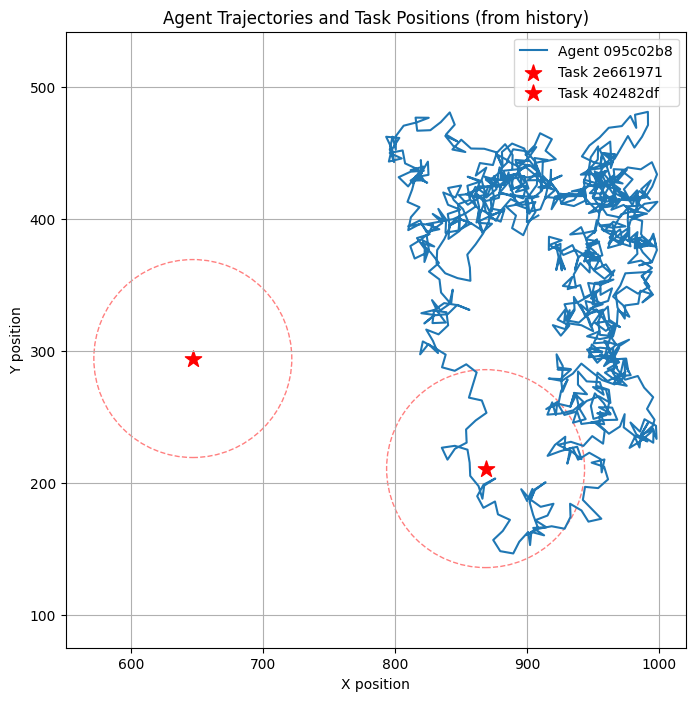

In [23]:
import matplotlib.pyplot as plt


# Plot agent trajectories from env.history
plt.figure(figsize=(8, 8))
for agent_id, agent_hist in env.history["agents"].items():
    if 'position' in agent_hist:
        x = [pos.x for pos in agent_hist['position']]
        y = [pos.y for pos in agent_hist['position']]
        plt.plot(x, y, label=f'Agent {str(agent_id)[:8]}')

# Get task radius from history if available, else from env
if 'radius' in env.history['tasks']:
    task_radius = env.history['tasks']['radius']
else:
    task_radius = env.task_radius

# Plot task positions and radii from env.history (initial and respawned)
for task_id, task_hist in env.history["tasks"].items():
    if isinstance(task_hist, dict) and 'position' in task_hist:
        pos = task_hist['position']
        plt.scatter(pos.x, pos.y, c='red', marker='*', s=150, label=f'Task {str(task_id)[:8]}')
        # Draw task radius as a circle
        circle = plt.Circle((pos.x, pos.y), task_radius, color='red', fill=False, linestyle='--', alpha=0.5)
        plt.gca().add_patch(circle)

plt.xlabel('X position')
plt.ylabel('Y position')
plt.title('Agent Trajectories and Task Positions (from history)')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()